# Trabajo práctico Nº 4: MÉTODOS DE REGULARIZACIÓN Y CART

## Confiugraciones preliminares

### Paquetes utilizados

In [44]:
# Paquetes empleados
import os 
import pandas as pd # Manipulacion de datos
import numpy as np # Calculos numericos
import matplotlib.pyplot as plt # Graficos
import matplotlib.cm as cm # Colores para graficos
import seaborn as sns # Grafico
import statsmodels.api as sm 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, Lasso, LassoCV, Ridge, RidgeCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, RocCurveDisplay, mean_squared_error, r2_score, recall_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, scale # Estandarizacion de datos


### Carga de archivos

In [2]:
# IMPORTAMOS LA BASE
#"C:\Users\juanc\Documents\GitHub\BigDataUBA-Grupo1\TP3\Program_TP3_Grupo1.ipynb" ruta juan notebook
#C:\Users\Usuario\Desktop\Maestria\Programacion\BigDataUBA-Grupo1\TP3\bases - Ruta juan pc escritorio
#r"C:\Users\AGUSTIN\Desktop\Maestría en Economía Aplicada - UBA\Segundo año\Taller de programacion\BigDataUBA-Grupo1\TP3\bases" - Ruta Agus
# C:\Repositorios\BigDataUBA-Grupo1\TP3\bases\ - Ruta Fran

ruta = r"C:\Repositorios\BigDataUBA-Grupo1\TP3\bases"
base = pd.read_excel(os.path.join(ruta, "respondieron_2025.xlsx"))

del ruta


In [3]:
# Configuración global de fuentes para gráficos

plt.rcParams.update({
    'font.size': 16,      # tamaño general de letras
    'axes.titlesize': 20  # tamaño de títulos
})

## Inspección de base de datos

In [4]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CODUSU                   4157 non-null   object 
 1   NRO_HOGAR                4157 non-null   int64  
 2   COMPONENTE               4157 non-null   int64  
 3   H15                      4157 non-null   int64  
 4   ANO4                     4157 non-null   int64  
 5   TRIMESTRE                4157 non-null   int64  
 6   REGION                   4157 non-null   int64  
 7   PONDERA                  4157 non-null   int64  
 8   CH03                     4157 non-null   int64  
 9   CH04                     4157 non-null   int64  
 10  CH06                     4157 non-null   int64  
 11  CH07                     4157 non-null   int64  
 12  CH08                     4157 non-null   int64  
 13  NIVEL_ED                 4157 non-null   int64  
 14  ESTADO                  

### Filtrado y puesta a punto de base de datos

In [5]:
# Filtrado de variables objetivos

categoricas = ["CH04", "CH07", "CH08", "ESTADO"]

for col in categoricas:
    base[col] = base[col].astype("category")

base=base.dropna(subset=['educ'])

del categoricas 

In [6]:
# VARIABLES EXPLICATIVAS y dependiente y separacion en train y test
vars_X = [
    "educ", "CH06", "edad2", "horastrab",
    "CH04", "IX_TOT", "CH07",
    "CH08", "ESTADO"
]

X=base[vars_X]
y= base['pobre']

# Corte 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444)

del vars_X

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4128 entries, 0 to 4156
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   educ       4128 non-null   float64 
 1   CH06       4128 non-null   int64   
 2   edad2      4128 non-null   int64   
 3   horastrab  4128 non-null   int64   
 4   CH04       4128 non-null   category
 5   IX_TOT     4128 non-null   int64   
 6   CH07       4128 non-null   category
 7   CH08       4128 non-null   category
 8   ESTADO     4128 non-null   category
dtypes: category(4), float64(1), int64(4)
memory usage: 210.4 KB


In [8]:
# Separamos las variables en numericas y categoricas para luego normalizar las numericas

cat_cols = ["CH04", "CH07", "CH08", "ESTADO"]
num_cols = [col for col in X_train.columns if col not in cat_cols]

X_train_num = X_train[num_cols].copy()
X_test_num  = X_test[num_cols].copy()

X_train_cat = X_train[cat_cols].copy()
X_test_cat  = X_test[cat_cols].copy()

In [9]:
# Escalamos las variables para aplicar ridge y lasso

scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train_num)
X_test_scaled_num  = scaler.transform(X_test_num)

#Transformo los arrays en dataframes
X_train_num_scaled = pd.DataFrame(X_train_scaled_num, 
                                  columns=num_cols, 
                                  index=X_train.index)

X_test_num_scaled = pd.DataFrame(X_test_scaled_num, 
                                 columns=num_cols, 
                                 index=X_test.index)


In [10]:
# Unión nuevamente los datasets

X_train_scaled = pd.concat([X_train_num_scaled, X_train_cat], axis=1)
X_test_scaled  = pd.concat([X_test_num_scaled, X_test_cat], axis=1)


## Parte A

### 1. Visualización

In [11]:
# La grilla de penalidades
n_values = np.arange(-5, 6)                 # -5 ... 5
lambdas = 10.0 ** n_values                  # lam = 10^n
C_values = 1 / lambdas                      # C = 1/lambda


In [12]:
#Lasso

coef_lasso = []

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',  # necesario para L1
        max_iter=500
    )
    model.fit(X_train_scaled, y_train)
    coef_lasso.append(model.coef_.flatten())
    
coef_lasso = np.array(coef_lasso)


In [13]:
#Ridge
coef_ridge = []

for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=500
    )
    model.fit(X_train_scaled, y_train)
    coef_ridge.append(model.coef_.flatten())

coef_ridge = np.array(coef_ridge)


#### Gráfico 

C:\Users\franl\AppData\Local\Temp\ipykernel_16708\1024444723.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(feature_names))


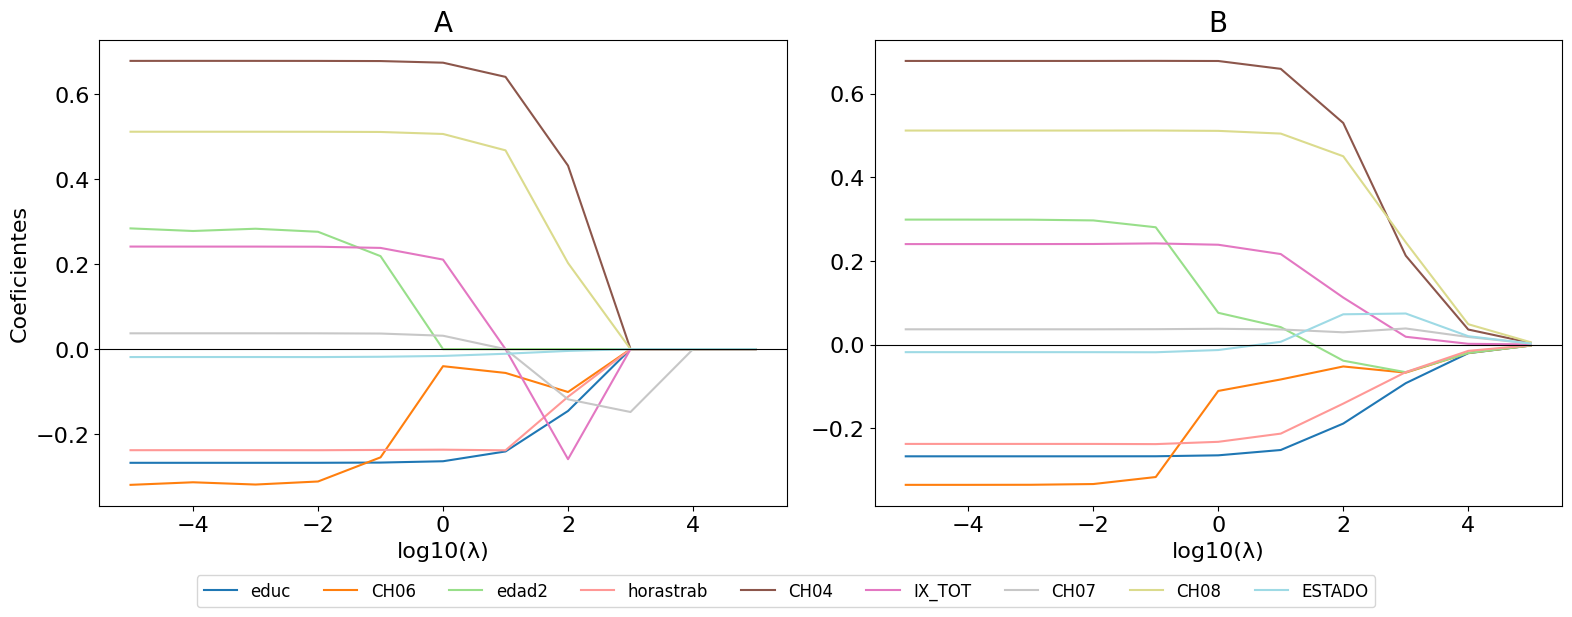

In [14]:

# Configuración global de fuentes
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20
})

# Obtener nombres de variables (columnas)
feature_names = X_train.columns

# Paleta de colores (ejemplo: tab20)
colors = cm.get_cmap("tab20", len(feature_names))

# Gráfico para los distintos valores de lambda
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------- LASSO -----------
for i, name in enumerate(feature_names):
    axes[0].plot(n_values, coef_lasso[:, i], label=name, color=colors(i))

axes[0].set_title("A")  # Coeficientes LASSO (L1)
axes[0].set_xlabel("log10(λ)")
axes[0].set_ylabel("Coeficientes")
axes[0].axhline(0, color="black", linewidth=0.8)

# ----------- RIDGE -----------
for i, name in enumerate(feature_names):
    axes[1].plot(n_values, coef_ridge[:, i], label=name, color=colors(i))

axes[1].set_title("B")  # Coeficientes Ridge (L2)
axes[1].set_xlabel("log10(λ)")
axes[1].set_ylabel("")
axes[1].axhline(0, color="black", linewidth=0.8)

# Leyenda única debajo de ambos gráficos
fig.legend(
    labels=feature_names,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),  # posición de la leyenda
    ncol=9,                       # cantidad de columnas de variables
    fontsize=12,
    frameon=True                  # Bordes de la leyenda
)

plt.tight_layout()
plt.show()

### 2.Penalidad optima para CV y visualización

In [22]:
#Entreno lasso con CV
logit_l1_cv = LogisticRegressionCV(
    Cs=C_values,                 # grilla de C
    cv=5,                        # 5-fold CV
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    max_iter=1000,
    refit=True
)

logit_l1_cv.fit(X_train_scaled, y_train)
best_model_lasso = logit_l1_cv


In [ ]:
#Recuperar la penalidad optima C y lambda

C_opt_l1 = logit_l1_cv.C_[0]
lambda_opt_l1 = 1 / C_opt_l1

C_opt_l1, lambda_opt_l1


(np.float64(99999.99999999999), np.float64(1e-05))

In [17]:
#Obtener el error promedio en cada lambda
mean_acc_l1 = logit_l1_cv.scores_[1].mean(axis=0)   # promedio accuracy por C
mean_err_l1 = 1 - mean_acc_l1                       # error de clasificación


In [18]:
#Entreno ridge con cv
logit_l2_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty='l2',
    solver='lbfgs',
    scoring='accuracy',
    max_iter=1000,
    refit=True
)

logit_l2_cv.fit(X_train_scaled, y_train)
best_model_ridge = logit_l2_cv    # este es el mejor modelo L2


In [19]:
#Recuperar la penalidad optima C y lambda
C_opt_l2 = logit_l2_cv.C_[0]
lambda_opt_l2 = 1 / C_opt_l2

C_opt_l2, lambda_opt_l2


(np.float64(1.0), np.float64(1.0))

In [20]:
#Obtener el error promedio en cada lambda
mean_acc_l2 = logit_l2_cv.scores_[1].mean(axis=0)
mean_err_l2 = 1 - mean_acc_l2


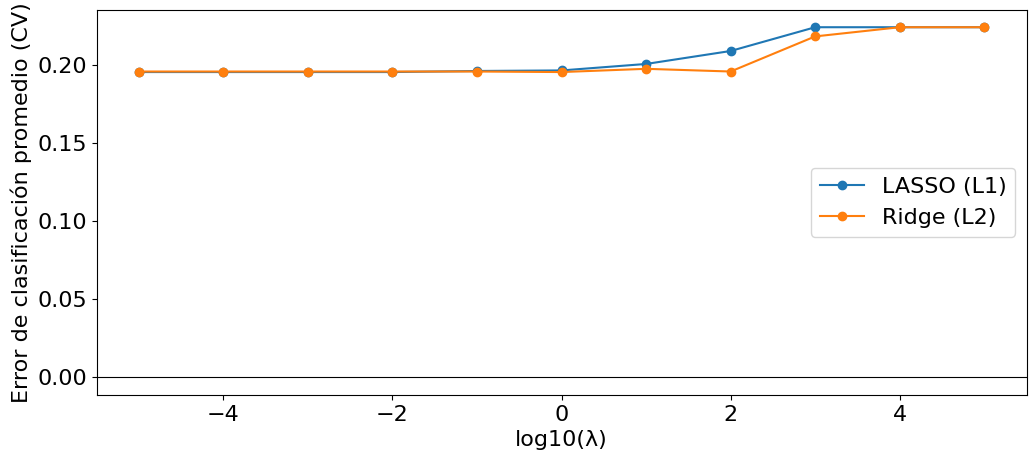

In [21]:
plt.figure(figsize=(12, 5))

# LASSO
plt.plot(n_values, mean_err_l1, marker='o', label="LASSO (L1)")

# RIDGE
plt.plot(n_values, mean_err_l2, marker='o', label="Ridge (L2)")

plt.axhline(0, color="black", linewidth=0.8)
plt.grid(False)
plt.xlabel("log10(λ)")
plt.ylabel("Error de clasificación promedio (CV)")
plt.title("") #Validación Cruzada 5-fold: Error vs penalidad λ
plt.legend()
plt.show()


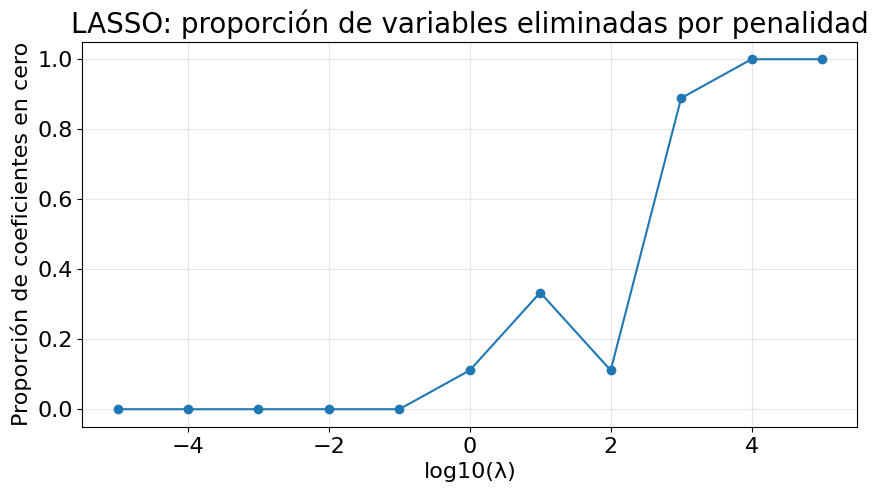

In [23]:
#Proporcion de variables eliminadas por lasso
coef_lasso = []

for C in C_values:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        max_iter=1000
    )
    model.fit(X_train_scaled, y_train)
    coef_lasso.append(model.coef_.flatten())

coef_lasso = np.array(coef_lasso)

# 3. Proporción de coeficientes cero
zero_props = (coef_lasso == 0).sum(axis=1) / coef_lasso.shape[1]

# 4. Gráfico
plt.figure(figsize=(10,5))
plt.plot(n_values, zero_props, marker='o')
plt.xlabel("log10(λ)")
plt.ylabel("Proporción de coeficientes en cero")
plt.title("LASSO: proporción de variables eliminadas por penalidad")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.show()


### 3. Estimacion con CV y comparacion de coeficientes

In [24]:
#Coeficientes, parametro c e interepto para LASSO
coef_lasso = logit_l1_cv.coef_.flatten()



In [25]:
#Coeficiente, parametro e intercepto para RIDGE
coef_ridge = logit_l2_cv.coef_.flatten()


In [ ]:
#Genero el logit sin penalidad
logit = LogisticRegression(
    penalty= None,
    solver='lbfgs',
    max_iter=1000
)

logit.fit(X_train_scaled, y_train)

coef_logit = logit.coef_.flatten()


In [28]:
# "C:\Users\Usuario\Desktop\Maestria\Programacion\BigDataUBA-Grupo1\TP4\" - Ruta Juan
# "C:\Repositorios\BigDataUBA-Grupo1\TP4\" - Ruta Fran

feature_names = X_train.columns
tabla_coef = pd.DataFrame({
    "Variable": feature_names,
    "Logit_sin_penalidad": coef_logit,
    "LASSO_(λ_opt)": coef_lasso,
    "Ridge_(λ_opt)": coef_ridge
})

tabla_coef.to_excel(r"C:\Repositorios\BigDataUBA-Grupo1\TP4\coeficientes_comparados.xlsx")

In [29]:
tabla_coef

,Variable,Logit_sin_penalidad,LASSO_(λ_opt),Ridge_(λ_opt)
0,educ,-0.267471,-0.267798,-0.264478
1,CH06,-0.335742,-0.317248,-0.191653
2,edad2,0.298789,0.282073,0.156618
3,horastrab,-0.237798,-0.237980,-0.233763
4,CH04,0.678333,0.679226,0.677548
5,IX_TOT,0.240210,0.241685,0.237029
6,CH07,0.036357,0.037318,0.037528
7,CH08,0.511806,0.512291,0.511477
8,ESTADO,-0.018301,-0.018534,-0.013386


## Parte B

### 4. Árbol de decisión podado (CART)

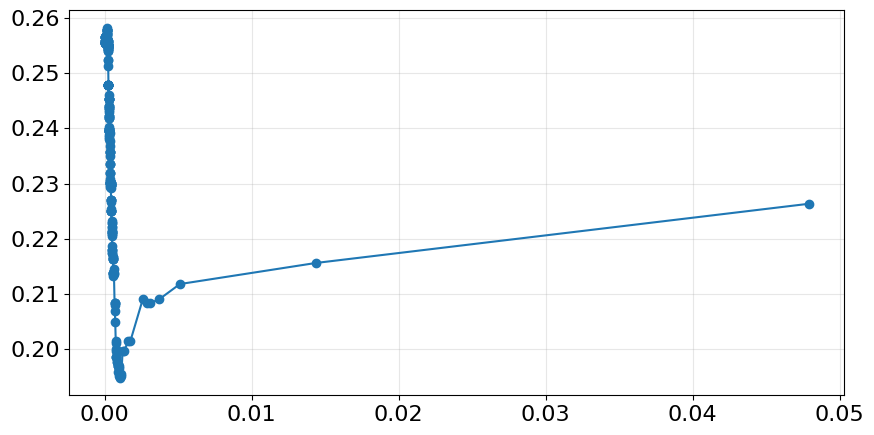

ccp_alpha óptimo: 0.0010782186572236112
Error mínimo de clasificación (CV): 0.19487336601307192


In [33]:
# Árbol inicial para obtener la ruta de poda y la grilla de ccp_alpha
tree_base = DecisionTreeClassifier(random_state=444)
tree_base.fit(X_train_scaled, y_train)

path = tree_base.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_values = path.ccp_alphas   # grilla de posibles valores de ccp_alpha

# Para cada alpha, estimar un árbol y calcular el error de clasificación promedio (10-fold CV)
cv_errors = []

for alpha in ccp_values:
    tree_temp = DecisionTreeClassifier(random_state=444, ccp_alpha=alpha)
    scores = cross_val_score(
        tree_temp,
        X_train_scaled,
        y_train,
        cv=10,
        scoring="accuracy"
    )
    mean_error = 1 - scores.mean()   # error de clasificación promedio
    cv_errors.append(mean_error)

cv_errors = np.array(cv_errors)

# Gráfico: error de clasificación vs ccp_alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_values, cv_errors, marker='o')
plt.xlabel("") # ccp_alpha
plt.ylabel("") # Error de clasificación (10-fold CV)
plt.title("") # Selección del costo de complejidad (CART)
plt.grid(True, alpha=0.3)
plt.show()

# Seleccionar el ccp_alpha óptimo (el que minimiza el error)
idx_opt = np.argmin(cv_errors)
alpha_opt = ccp_values[idx_opt]

print("ccp_alpha óptimo:", alpha_opt)
print("Error mínimo de clasificación (CV):", cv_errors[idx_opt])

### 5. Visualización del árbol podado por cross-validation

#### Panel A

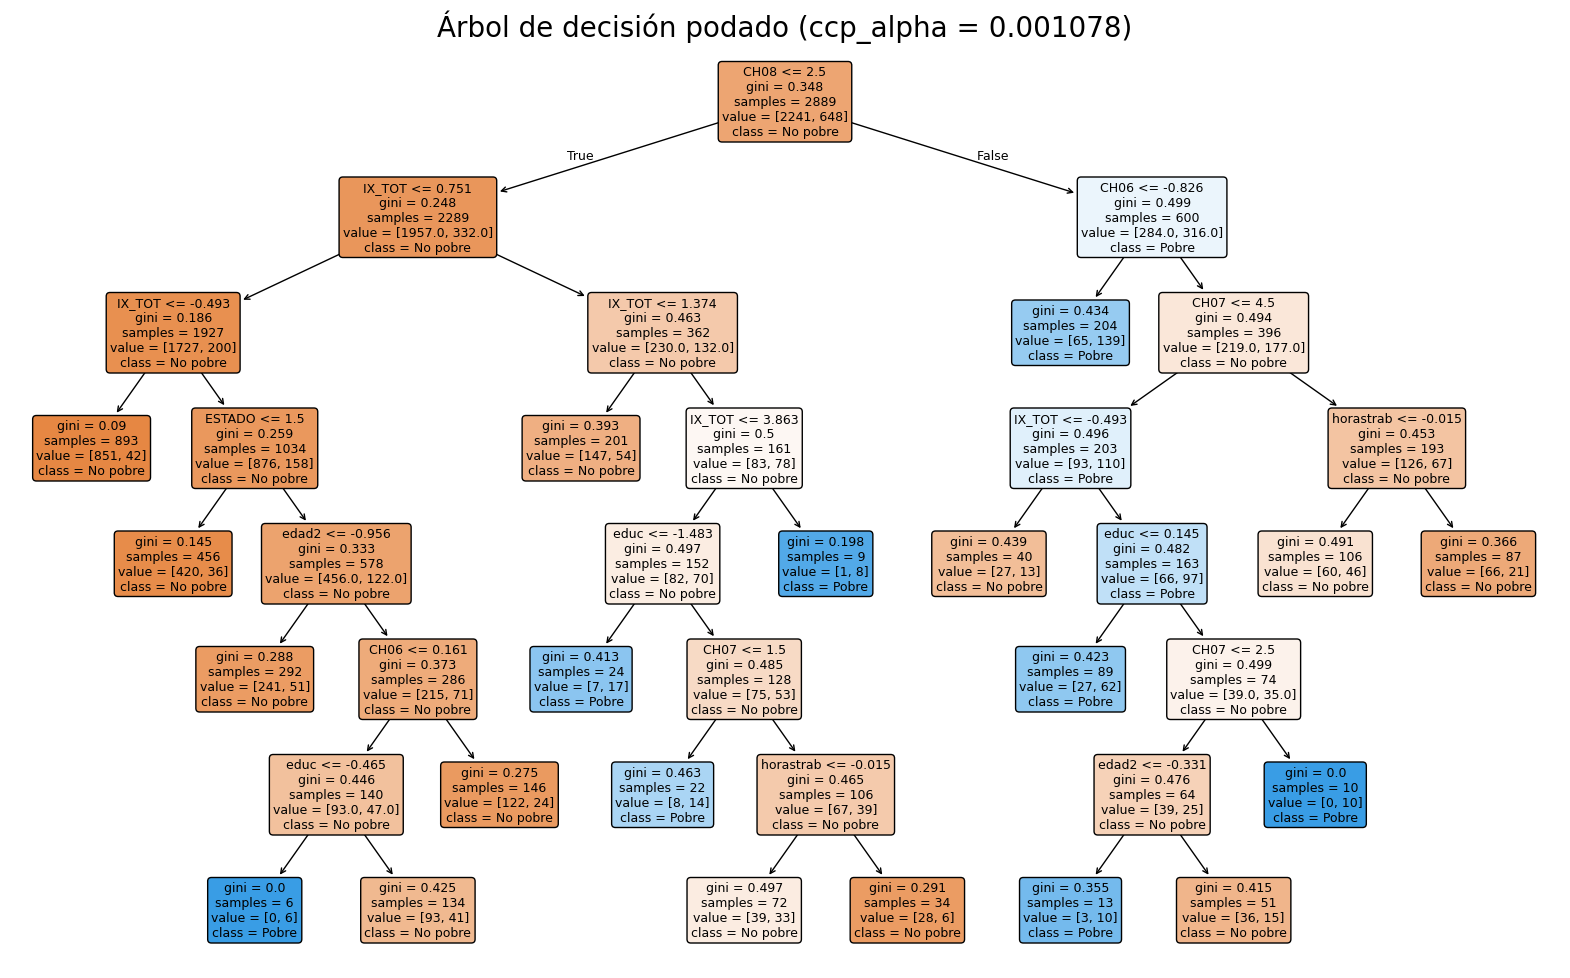

In [35]:
# Usamos el alpha optimo 
alpha_opt = 0.0010782186572236112 

# Entreno el árbol
tree_opt = DecisionTreeClassifier(
    random_state=444,
    ccp_alpha=alpha_opt
)
tree_opt.fit(X_train_scaled, y_train)

# Preparo nombres de variables como lista
feature_names = list(X_train_scaled.columns)

# PANEL A: Árbol podado
plt.figure(figsize=(20, 12))
plot_tree(
    tree_opt,
    feature_names=feature_names,        
    class_names=["No pobre", "Pobre"],
    impurity=True,
    rounded=True,
    filled=True,
    fontsize=9
)
plt.title(f"Árbol de decisión podado (ccp_alpha = {alpha_opt:.6f})")
plt.show()

#### Panel B

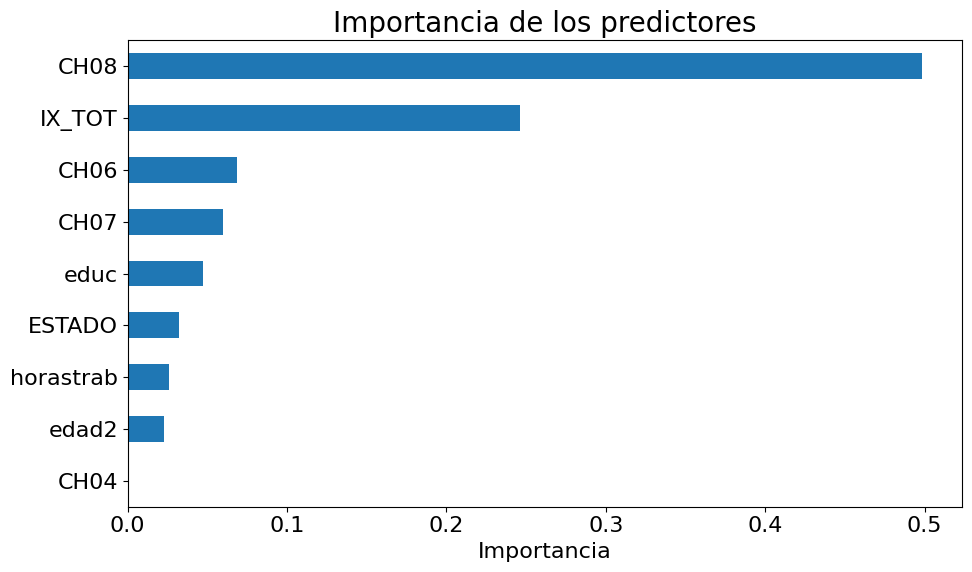

In [34]:
# PANEL B: Importancia de variables
importances = pd.Series(tree_opt.feature_importances_, index=feature_names)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind="barh")
plt.xlabel("Importancia")
plt.title("Importancia de los predictores")
plt.tight_layout()
plt.show()

## Parte C

In [55]:
# Cargando modelo KNN del TP3

import joblib

# C:\Repositorios\BigDataUBA-Grupo1\TP4 - Ruta Fran

# Cargar el modelo KNN-CV previamente guardado
best_knn = joblib.load("C:\Repositorios\BigDataUBA-Grupo1\TP4\modelo_knn_cv.pkl")

# Obtener probabilidades en el set de test
prob_knn = best_knn.predict_proba(X_test)[:,1]

<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\franl\AppData\Local\Temp\ipykernel_16708\1292191906.py:8: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  best_knn = joblib.load("C:\Repositorios\BigDataUBA-Grupo1\TP4\modelo_knn_cv.pkl")


Logit sin penalidad:
 [[910  57]
 [179  93]]
KNN (K-CV):
 [[901  66]
 [170 102]]
Logit LASSO:
 [[910  57]
 [179  93]]
Logit Ridge:
 [[910  57]
 [180  92]]
Árbol podado:
 [[902  65]
 [176  96]]
Logit: Accuracy=0.810, Error=0.190, Recall=0.342
KNN: Accuracy=0.810, Error=0.190, Recall=0.375
LASSO: Accuracy=0.810, Error=0.190, Recall=0.342
Ridge: Accuracy=0.809, Error=0.191, Recall=0.338
Árbol: Accuracy=0.805, Error=0.195, Recall=0.353


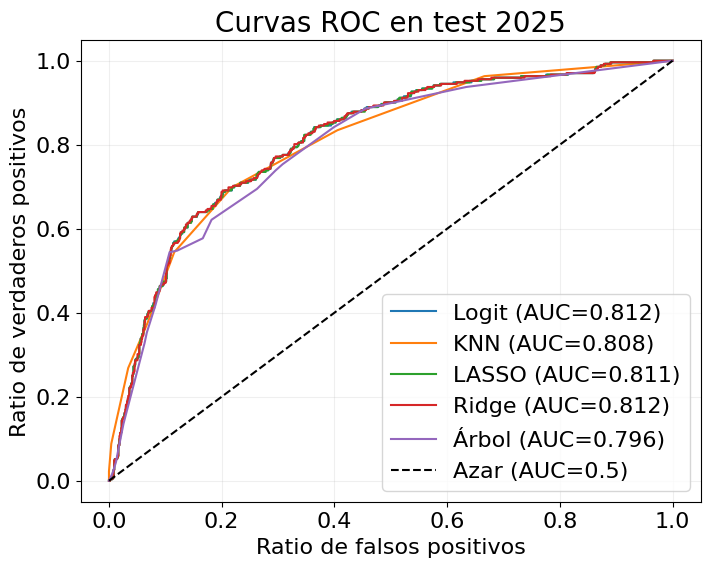

In [58]:
# Probabilidades de cada modelo
prob_logit  = logit.predict_proba(X_test_scaled)[:,1]        # TP4 logit sin penalidad
prob_lasso  = best_model_lasso.predict_proba(X_test_scaled)[:,1]
prob_ridge  = best_model_ridge.predict_proba(X_test_scaled)[:,1]
prob_tree   = tree_opt.predict_proba(X_test_scaled)[:,1]
prob_knn    = best_knn.predict_proba(X_test)[:,1]            # TP3 KNN con CV

# Matrices de confusión (p > 0.5)
print("Logit sin penalidad:\n", confusion_matrix(y_test, (prob_logit>=0.5).astype(int)))
print("KNN (K-CV):\n", confusion_matrix(y_test, (prob_knn>=0.5).astype(int)))
print("Logit LASSO:\n", confusion_matrix(y_test, (prob_lasso>=0.5).astype(int)))
print("Logit Ridge:\n", confusion_matrix(y_test, (prob_ridge>=0.5).astype(int)))
print("Árbol podado:\n", confusion_matrix(y_test, (prob_tree>=0.5).astype(int)))

# Métricas principales (accuracy y recall)
for nombre, prob in {
    "Logit": prob_logit,
    "KNN": prob_knn,
    "LASSO": prob_lasso,
    "Ridge": prob_ridge,
    "Árbol": prob_tree
}.items():
    y_pred = (prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"{nombre}: Accuracy={acc:.3f}, Error={1-acc:.3f}, Recall={rec:.3f}")

# Curvas ROC comparativas
plt.figure(figsize=(8,6))
for nombre, prob in {
    "Logit": prob_logit,
    "KNN": prob_knn,
    "LASSO": prob_lasso,
    "Ridge": prob_ridge,
    "Árbol": prob_tree
}.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc_val:.3f})")
plt.plot([0,1],[0,1],'k--',label="Azar (AUC=0.5)")
plt.xlabel("Ratio de falsos positivos")
plt.ylabel("Ratio de verdaderos positivos")
plt.title("Curvas ROC en test 2025")
plt.legend()
plt.grid(alpha=0.2)
plt.show()